<a href="https://colab.research.google.com/github/Williams-MP/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/blob/main/APR_Proyecto_pr%C3%A1ctico_Maria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad - Proyecto práctico


> La actividad se desarrollará en grupos pre-definidos de 4 alumnos. Se debe indicar los nombres en orden alfabético (de apellidos). Recordad que esta actividad se corresponde con un 30% de la nota final de la asignatura. Se debe entregar entregar el trabajo en la presente notebook.
*   Alumno 1:
*   Alumno 2:
*   Alumno 3:
*   Alumno 4:






---
## **PARTE 1** - Instalación y requisitos previos

> Las prácticas han sido preparadas para poder realizarse en el entorno de trabajo de Google Colab. Sin embargo, esta plataforma presenta ciertas incompatibilidades a la hora de visualizar la renderización en gym. Por ello, para obtener estas visualizaciones, se deberá trasladar el entorno de trabajo a local. Por ello, el presente dosier presenta instrucciones para poder trabajar en ambos entornos. Siga los siguientes pasos para un correcto funcionamiento:
1.   **LOCAL:** Preparar el enviroment, siguiendo las intrucciones detalladas en la sección *1.1.Preparar enviroment*.
2.  **AMBOS:** Modificar las variables "mount" y "drive_mount" a la carpeta de trabajo en drive en el caso de estar en Colab, y ejecturar la celda *1.2.Localizar entorno de trabajo*.
3. **COLAB:** se deberá ejecutar las celdas correspondientes al montaje de la carpeta de trabajo en Drive. Esta corresponde a la sección *1.3.Montar carpeta de datos local*.
4.  **AMBOS:** Instalar las librerías necesarias, siguiendo la sección *1.4.Instalar librerías necesarias*.


---
### 1.1. Preparar enviroment (solo local)



> Para preparar el entorno de trabajo en local, se han seguido los siguientes pasos:
1. En Windows, puede ser necesario instalar las C++ Build Tools. Para ello, siga los siguientes pasos. Alternativamente puedes utilizar WSL2: https://towardsdatascience.com/how-to-install-openai-gym-in-a-windows-environment-338969e24d30.
2. Instalar Anaconda
3. Siguiendo el código que se presenta comentado en la próxima celda: Crear un enviroment, cambiar la ruta de trabajo, e instalar librerías básicas.


```
conda create --name miar_rl python=3.8
conda activate miar_rl
cd "PATH_TO_FOLDER"
conda install git
pip install jupyter
```


4. Abrir la notebook con *jupyter-notebook*.



```
jupyter-notebook
```


---
### 1.2. Localizar entorno de trabajo: Google colab o local

In [2]:
# ATENCIÓN!! Modificar ruta relativa a la práctica si es distinta (drive_root)
mount = '/content/gdrive'
drive_root = mount + "/My Drive/Proyecto_RL_Enduro"

try:
    from google.colab import drive
    IN_COLAB = True
except:
    IN_COLAB = False

print("Estoy en Colab:", IN_COLAB)
print("Ruta de trabajo:", drive_root)

Estoy en Colab: True
Ruta de trabajo: /content/gdrive/My Drive/Proyecto_RL_Enduro


---
### 1.3. Montar carpeta de datos local (solo Colab)

In [2]:
import os

if IN_COLAB:
    drive.mount(mount)
    os.makedirs(drive_root, exist_ok=True)
    %cd $drive_root

print("Carpeta creada/existente:", os.path.exists(drive_root))
print("Ruta final:", drive_root)

print("Directorio actual:")
%pwd

print("Archivos en el directorio:")
print(os.listdir())

Mounted at /content/gdrive
/content/gdrive/My Drive/Proyecto_RL_Enduro
Carpeta creada/existente: True
Ruta final: /content/gdrive/My Drive/Proyecto_RL_Enduro
Directorio actual:
Archivos en el directorio:
[]


---
### 1.4. Instalar librerías necesarias

In [3]:
if IN_COLAB:
  %pip install tensorflow==2.18.0
  %pip install tf-keras==2.18.0
  %pip install gym==0.17.3
  %pip install git+https://github.com/Kojoley/atari-py.git
  %pip install keras-rl2==1.0.5
else:
  %pip install gym==0.17.3
  %pip install git+https://github.com/Kojoley/atari-py.git
  %pip install pyglet==1.5.0
  %pip install h5py==3.1.0
  %pip install Pillow==9.5.0
  %pip install keras-rl2==1.0.5
  %pip install Keras==2.2.4
  %pip install tensorflow==2.5.3
  %pip install torch==2.0.1
  %pip install agents==1.4.0

  Cloning https://github.com/Kojoley/atari-py.git to /tmp/pip-req-build-upunieez
  Running command git clone --filter=blob:none --quiet https://github.com/Kojoley/atari-py.git /tmp/pip-req-build-upunieez
  Resolved https://github.com/Kojoley/atari-py.git to commit 86a1e05c0a95e9e6233c3a413521fdb34ca8a089
  Preparing metadata (setup.py) ... done
  Created wheel for atari-py: filename=atari_py-1.2.2-cp312-cp312-linux_x86_64.whl size=4739376 sha256=10fd0d684004fdde5f98aee081e6348618119dd91698694b84e759634894456c
  Stored in directory: /tmp/pip-ephem-wheel-cache-8_ue8tqd/wheels/cb/1f/56/35b393898f74ae3d978063738e8eeb4b3d7357d0d7eeec6b9f
Successfully built atari-py
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.1/52.1 kB 3.4 MB/s eta 0:00:00


In [4]:
%pip uninstall -y jax jaxlib

### Verificación de instalación y GPU

In [5]:
#1
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

from PIL import Image
import numpy as np
import gym

import tensorflow as tf
import tf_keras

# Usamos SIEMPRE tf_keras para construir el modelo
from tf_keras.models import Sequential
from tf_keras.layers import Dense, Activation, Flatten, Conv2D, Permute
from tf_keras.optimizers.legacy import Adam
import tf_keras.backend as K

# Parche para keras-rl2
import tensorflow.keras as tfk
tfk.__version__ = tf_keras.__version__

from rl.agents.dqn import DQNAgent
from rl.policy import LinearAnnealedPolicy, BoltzmannQPolicy, EpsGreedyQPolicy
from rl.memory import SequentialMemory
from rl.core import Processor
from rl.callbacks import FileLogger, ModelIntervalCheckpoint

print("TensorFlow:", tf.__version__)
print("tf_keras:", tf_keras.__version__)
print("Gym:", gym.__version__)
print("Sequential viene de:", Sequential.__module__)
print("keras-rl2 importado correctamente")

TensorFlow: 2.18.0
tf_keras: 2.18.0
Gym: 0.17.3
Sequential viene de: tf_keras.src.engine.sequential
keras-rl2 importado correctamente


---
## **PARTE 2**. Enunciado

Consideraciones a tener en cuenta:

- El entorno sobre el que trabajaremos será el indicado en el listado correspondien de cada grupo y el algoritmo que usaremos será _DQN_.

- Para nuestro ejercicio, el requisito mínimo será alcanzado cuando el agente consiga una **media de recompensa por encima de los puntos indicados en el listado por grupos en modo test**. Por ello, esta media de la recompensa se calculará a partir del código de test en la última celda del notebook.

Este proyecto práctico consta de tres partes:

1.   Implementar la red neuronal que se usará en la solución
2.   Implementar las distintas piezas de la solución DQN y probar al menos 3 propuestas diferentes de mejora.
3.   Justificar la respuesta en relación a los resultados obtenidos e incluir al menos 3 gráficas relevantes comparando las 3 propuestas.

**Rúbrica**: Se valorará la originalidad en la solución aportada, así como la capacidad de discutir los resultados de forma detallada. El requisito mínimo servirá para aprobar la actividad, bajo premisa de que la discusión del resultado sera apropiada.

IMPORTANTE:

* Si no se consigue una puntuación óptima, responder sobre la mejor puntuación obtenida.
* Para entrenamientos largos, recordad que podéis usar checkpoints de vuestros modelos para retomar los entrenamientos. En este caso, recordad cambiar los parámetros adecuadamente (sobre todo los relacionados con el proceso de exploración).
* Se deberá entregar unicamente el notebook y los pesos del mejor modelo en un fichero .zip, de forma organizada.
* Cada alumno deberá de subir la solución de forma individual.

---
## **PARTE 3**. Desarrollo y preguntas

#### Importar librerías

#### Configuración base

En esta celda se configura el entorno Enduro de Atari. Se define el tamaño de entrada que utilizará la red neuronal después del preprocesamiento de las imágenes, estableciendo frames de 84x84 píxeles y una ventana temporal de 4 frames consecutivos.

Luego se crea el entorno mediante Gym, se fija una semilla para mejorar la reproducibilidad y se obtiene el número de acciones disponibles. Este valor será utilizado para definir la cantidad de neuronas de salida de la red DQN, ya que el modelo debe estimar un valor Q para cada acción posible.

In [6]:
#2
INPUT_SHAPE = (84, 84)
WINDOW_LENGTH = 4

env_name = 'Enduro-v0'
env = gym.make(env_name)

np.random.seed(123)
env.seed(123)

nb_actions = env.action_space.n

print("Entorno:", env_name)
print("Número de acciones:", nb_actions)
print("Espacio de observación:", env.observation_space)
print("Espacio de acciones:", env.action_space)

Entorno: Enduro-v0
Número de acciones: 9
Espacio de observación: Box(0, 255, (210, 160, 3), uint8)
Espacio de acciones: Discrete(9)


La clase `AtariProcessor` se encarga de preprocesar las observaciones y recompensas antes de que sean utilizadas por el agente DQN. Las imágenes originales del entorno Enduro tienen tamaño 210x160x3 y se transforman a escala de grises con tamaño 84x84, reduciendo la dimensionalidad de entrada de la red.

Además, los lotes de estados se normalizan dividiendo los valores de píxel por 255, de modo que queden en el rango [0, 1]. Finalmente, las recompensas se recortan al intervalo [-1, 1], una práctica habitual en DQN para entornos Atari que ayuda a estabilizar el aprendizaje.

In [7]:
#3
class AtariProcessor(Processor):
    def process_observation(self, observation):
        assert observation.ndim == 3  # (height, width, channel)
        img = Image.fromarray(observation)
        img = img.resize(INPUT_SHAPE).convert('L')
        processed_observation = np.array(img)
        assert processed_observation.shape == INPUT_SHAPE
        return processed_observation.astype('uint8')

    def process_state_batch(self, batch):
        processed_batch = batch.astype('float32') / 255.
        return processed_batch

    def process_reward(self, reward):
        return np.clip(reward, -1., 1.)

1. Implementación de la red neuronal

In [8]:
#4
import tensorflow as tf
import numpy as np
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, Activation, Flatten, Conv2D, Permute

# Limpiamos modelos anteriores
K.clear_session()

# Red neuronal DQN
model = Sequential()

# Entrada explícita
model.add(InputLayer(input_shape=(WINDOW_LENGTH,) + INPUT_SHAPE))

# Reorganiza de (4, 84, 84) a (84, 84, 4)
model.add(Permute((2, 3, 1)))

# Capas convolucionales
model.add(Conv2D(32, (8, 8), strides=(4, 4)))
model.add(Activation('relu'))

model.add(Conv2D(64, (4, 4), strides=(2, 2)))
model.add(Activation('relu'))

model.add(Conv2D(64, (3, 3), strides=(1, 1)))
model.add(Activation('relu'))

# Capas densas
model.add(Flatten())

model.add(Dense(512))
model.add(Activation('relu'))

# Salida: una neurona por acción
model.add(Dense(nb_actions))
model.add(Activation('linear'))

# Forzamos que el modelo quede construido/llamado
dummy_input = np.zeros((1, WINDOW_LENGTH, INPUT_SHAPE[0], INPUT_SHAPE[1]), dtype='float32')
_ = model(dummy_input)

model.summary()

print("Forma de entrada:", model.input_shape)
print("Forma de salida:", model.output_shape)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 permute (Permute)           (None, 84, 84, 4)         0         
                                                                 
 conv2d (Conv2D)             (None, 20, 20, 32)        8224      
                                                                 
 activation (Activation)     (None, 20, 20, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 9, 9, 64)          32832     
                                                                 
 activation_1 (Activation)   (None, 9, 9, 64)          0         
                                                                 
 conv2d_2 (Conv2D)           (None, 7, 7, 64)          36928     
                                                                 
 activation_2 (Activation)   (None, 7, 7, 64)          0

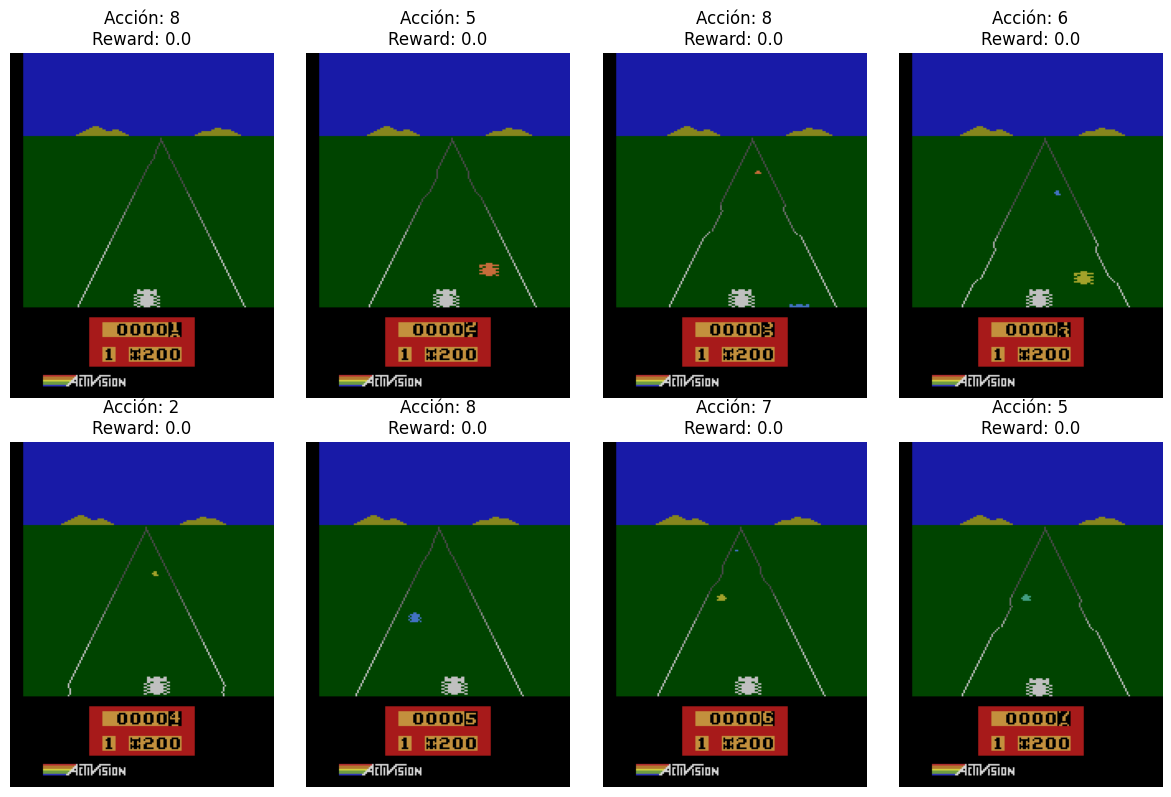

In [ ]:
import matplotlib.pyplot as plt

obs = env.reset()

plt.figure(figsize=(12, 8))

for i in range(8):
    # Avanzamos varios pasos antes de tomar la imagen
    total_reward = 0
    last_action = None

    for _ in range(20):
        action = env.action_space.sample()
        obs, reward, done, info = env.step(action)
        total_reward += reward
        last_action = action

        if done:
            obs = env.reset()
            break

    plt.subplot(2, 4, i + 1)
    plt.imshow(obs)
    plt.title(f"Acción: {last_action}\nReward: {total_reward}")
    plt.axis("off")

plt.tight_layout()
plt.show()

2. Implementación de la solución DQN

In [9]:
#5
# Memoria de experiencias
memory = SequentialMemory(
    limit=500000,
    window_length=WINDOW_LENGTH
)

# Política epsilon-greedy con reducción gradual de exploración
policy = LinearAnnealedPolicy(
    EpsGreedyQPolicy(),
    attr='eps',
    value_max=1.0,
    value_min=0.1,
    value_test=0.05,
    nb_steps=500000
)

# Creación del agente DQN
dqn = DQNAgent(
    model=model,
    nb_actions=nb_actions,
    memory=memory,
    processor=AtariProcessor(),
    policy=policy,
    nb_steps_warmup=1000,
    gamma=0.99,
    target_model_update=10000,
    train_interval=4,
    delta_clip=1.
)

# Compilación del agente
dqn.compile(
    Adam(learning_rate=0.00025),
    metrics=['mae']
)

print("Agente DQN creado y compilado correctamente")

Agente DQN creado y compilado correctamente


In [10]:
# Entrenamiento de prueba con aprendizaje real

weights_filename = f'dqn_{env_name}_weights_50000.h5f'
checkpoint_weights_filename = f'dqn_{env_name}_weights_{{step}}.h5f'
log_filename = f'dqn_{env_name}_log_50000.json'

callbacks = [
    ModelIntervalCheckpoint(checkpoint_weights_filename, interval=10000),
    FileLogger(log_filename, interval=1000)
]

history = dqn.fit(
    env,
    callbacks=callbacks,
    nb_steps=50000,
    log_interval=1000,
    visualize=False,
    verbose=2
)

dqn.save_weights(weights_filename, overwrite=True)

print("Entrenamiento de 50000 pasos finalizado")

Training for 50000 steps ...


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training_v1.py:2354: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


  4438/50000: episode: 1, duration: 125.565s, episode steps: 4438, steps per second:  35, episode reward:  0.000, mean reward:  0.000 [ 0.000,  0.000], mean action: 4.003 [0.000, 8.000],  loss: 0.000031, mae: 0.084674, mean_q: 0.100657, mean_eps: 0.995104
  8891/50000: episode: 2, duration: 158.108s, episode steps: 4453, steps per second:  28, episode reward:  0.000, mean reward:  0.000 [ 0.000,  0.000], mean action: 3.938 [0.000, 8.000],  loss: 0.000011, mae: 0.077512, mean_q: 0.090503, mean_eps: 0.988005
 13340/50000: episode: 3, duration: 159.378s, episode steps: 4449, steps per second:  28, episode reward:  0.000, mean reward:  0.000 [ 0.000,  0.000], mean action: 3.937 [0.000, 8.000],  loss: 0.000010, mae: 0.079136, mean_q: 0.091757, mean_eps: 0.979995
 17782/50000: episode: 4, duration: 159.096s, episode steps: 4442, steps per second:  28, episode reward:  0.000, mean reward:  0.000 [ 0.000,  0.000], mean action: 3.980 [0.000, 8.000],  loss: 0.000005, mae: 0.079476, mean_q: 0.091

/usr/local/lib/python3.12/dist-packages/rl/core.py:206: RuntimeWarning: overflow encountered in scalar add
  self.step += 1


 35554/50000: episode: 8, duration: 70.645s, episode steps: 4423, steps per second:  63, episode reward:  0.000, mean reward:  0.000 [ 0.000,  0.000], mean action: 4.092 [0.000, 8.000],  loss: 0.000005, mae: 0.083041, mean_q: 0.094905, mean_eps: 0.942494
 40002/50000: episode: 9, duration: 20.772s, episode steps: 4448, steps per second: 214, episode reward:  0.000, mean reward:  0.000 [ 0.000,  0.000], mean action: 4.061 [0.000, 8.000],  loss: --, mae: --, mean_q: --, mean_eps: --
 44454/50000: episode: 10, duration: 19.513s, episode steps: 4452, steps per second: 228, episode reward:  0.000, mean reward:  0.000 [ 0.000,  0.000], mean action: 3.992 [0.000, 8.000],  loss: --, mae: --, mean_q: --, mean_eps: --
 48878/50000: episode: 11, duration: 18.696s, episode steps: 4424, steps per second: 237, episode reward:  0.000, mean reward:  0.000 [ 0.000,  0.000], mean action: 3.955 [0.000, 8.000],  loss: --, mae: --, mean_q: --, mean_eps: --
 53342/50000: episode: 12, duration: 20.214s, epis

3. Justificación de los parámetros seleccionados y de los resultados obtenidos

---